#### Complete Preprocessing of NSL-KDD Dataset

Step 1: Load the Dataset

In [1]:
import pandas as pd

# Load NSL-KDD training data
data = pd.read_csv("C:\\Users\\pm5cd\\Documents\\SentinelNet-AI\\SentinelNet\\data\\NSL-KDD\\KDDTrain+.txt", header=None)

# Add column names (from NSL-KDD documentation)
columns = (['duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot'
,'num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations'
,'num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate'
,'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count'
,'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate'
,'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','outcome','label'])
data.columns = columns
print(data.head())


   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.60                         0.88   
2             

Step 2: Handle Missing Values

In [2]:
# Check missing values
print(data.isnull().sum().sum())  # NSL-KDD usually has no NaNs

# If there were NaNs (just in case):
for col in data.select_dtypes(include=['int64','float64']).columns:
    data[col] = data[col].fillna(data[col].median())

for col in data.select_dtypes(include=['object']).columns:
    data[col] = data[col].fillna(data[col].mode()[0])


0


Step 3: Encode Labels (Attack vs Normal)

In [3]:
# Group attacks into "normal" vs "attack"
data['label'] = data['label'].apply(lambda x: "normal" if x == "normal" else "attack")

from sklearn.preprocessing import LabelEncoder
label_enc = LabelEncoder()
data['label'] = label_enc.fit_transform(data['label'])  # normal=0, attack=1


Step 4: Encode Categorical Features

In [4]:
categorical_cols = ["protocol_type", "service", "flag"]

# One-hot encode categorical variables
data = pd.get_dummies(data, columns=categorical_cols)


Step 5: Feature Scaling (Standardization)

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numeric_cols = data.drop("label", axis=1).select_dtypes(include=['int64','float64']).columns
data[numeric_cols] = scaler.fit_transform(data[numeric_cols])


Step 6: Outlier Handling

In [6]:
import numpy as np

# Clip extreme values at 3 standard deviations
for col in numeric_cols:
    mean, std = data[col].mean(), data[col].std()
    data[col] = np.clip(data[col], mean - 3*std, mean + 3*std)

Step 7: Feature Engineering

In [7]:
# Add new meaningful features
data["bytes_sum"] = data["src_bytes"] + data["dst_bytes"]
data["bytes_diff"] = data["src_bytes"] - data["dst_bytes"]


Step 8: Dimensionality Reduction

In [8]:
from sklearn.decomposition import PCA

X = data.drop(["label", "outcome"], axis=1)
y = data["label"]

pca = PCA(n_components=20)   # reduce to 20 principal components
X_pca = pca.fit_transform(X)

print("Original Shape:", X.shape)
print("Reduced Shape:", X_pca.shape)


Original Shape: (125973, 124)
Reduced Shape: (125973, 20)


Step 9: Handle Class Imbalance

In [9]:
from imblearn.over_sampling import SMOTE

if len(y.unique()) > 1:
	sm = SMOTE(random_state=42)
	X_res, y_res = sm.fit_resample(X_pca, y)
	print("Before:", y.value_counts())
	print("After:", pd.Series(y_res).value_counts())
else:
	print("SMOTE not applied: Only one class present in y.")
	print("Class distribution:", y.value_counts())


SMOTE not applied: Only one class present in y.
Class distribution: label
0    125973
Name: count, dtype: int64


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Sample dataset creation for demonstration
np.random.seed(0)
data = pd.DataFrame({
    'numeric_feature': np.random.randn(100),
    'categorical_feature': np.random.choice(['A', 'B', 'C', 'D'], size=100),
    'high_card_feature': np.random.choice([f'category_{i}' for i in range(50)], size=100),
    'missing_feature': np.random.choice([np.nan, 1, 2, 3], size=100),
    'target': np.random.choice([0, 1], size=100, p=[0.8, 0.2])
})

# Sparse feature example: Binary sparse encoding
data['sparse_feature'] = data['categorical_feature'].apply(lambda x: 1 if x == 'A' else 0)

# Data validation function example
def validate_data(df):
    assert all(df['numeric_feature'].between(-5, 5)), "Numeric feature out of range"
    assert df['categorical_feature'].isin(['A', 'B', 'C', 'D']).all(), "Invalid categorical value"
    print('Data validation passed.')

validate_data(data)

# Handling missing data with imputation
numeric_imputer = SimpleImputer(strategy='mean')
categorical_imputer = SimpleImputer(strategy='most_frequent')

# Categorical encoding: One-hot encoder with ignore unknown for unseen categories
onehot_encoder = OneHotEncoder(handle_unknown='ignore')

# Handling high cardinality with frequency encoding
freq_encoding = data['high_card_feature'].value_counts(normalize=True)
data['high_card_freq_encoded'] = data['high_card_feature'].map(freq_encoding)

# Define numeric and categorical features for preprocessing pipeline
numeric_features = ['numeric_feature', 'missing_feature']
categorical_features = ['categorical_feature']

# Preprocessing pipelines
numeric_transformer = Pipeline([
    ('imputer', numeric_imputer),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', categorical_imputer),
    ('onehot', onehot_encoder)
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Discretization of numeric_feature into 5 bins (equal-width)
data['numeric_disc'] = pd.cut(data['numeric_feature'], bins=5, labels=False)

# Feature integration example: Merging with extra data
extra_data = pd.DataFrame({
    'id': range(50),
    'additional_info': np.random.randn(50)
})
data = data.reset_index().rename(columns={'index': 'id'})
merged_data = pd.merge(data, extra_data, on='id', how='left')
print('Data integration completed. Merged data shape:', merged_data.shape)

# Note on imbalanced data handling:
# For imbalanced data (like here with target 0.8/0.2), synthetic oversampling (e.g. SMOTE) is recommended.
# SMOTE requires the 'imblearn' package, which should be installed separately.
# Alternatively, undersampling or class_weight parameter in classifiers can be used.

# Example model training pipeline
X = preprocessor.fit_transform(data)
y = data['target']

# Basic model training (without SMOTE here)
clf = RandomForestClassifier(random_state=42, class_weight='balanced')
clf.fit(X, y)

# Prediction and evaluation
preds = clf.predict(X)
print(classification_report(y, preds))


Data validation passed.
Data integration completed. Merged data shape: (100, 10)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        83
           1       1.00      1.00      1.00        17

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



Data validation passed.


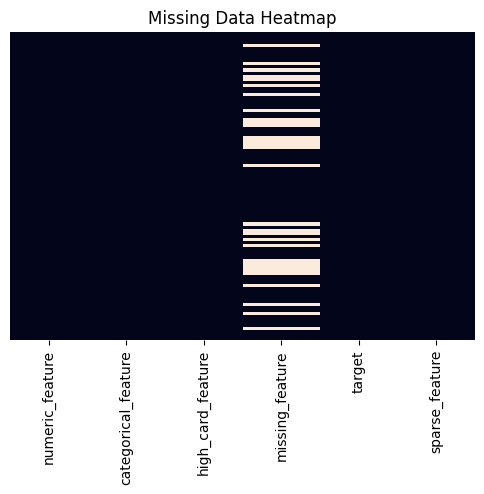

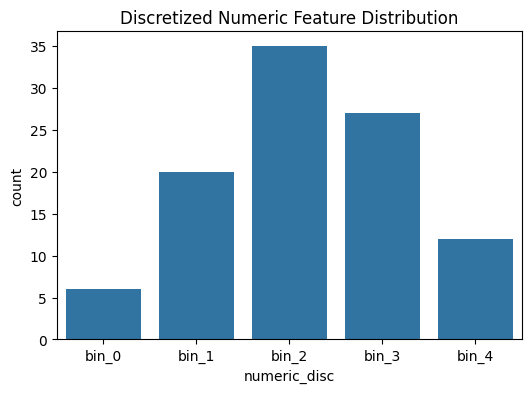

Data integrated. Shape: (100, 10)


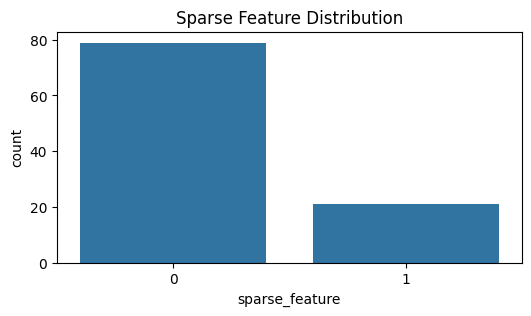

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        83
           1       1.00      1.00      1.00        17

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



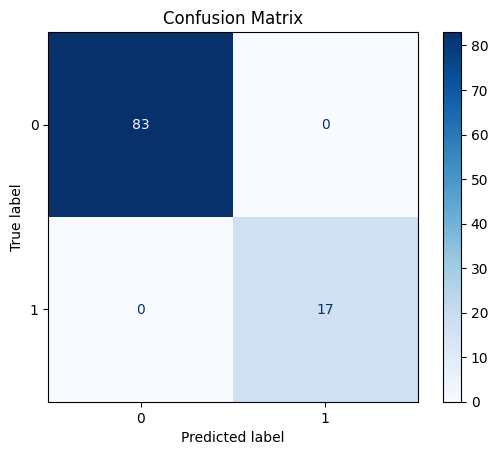

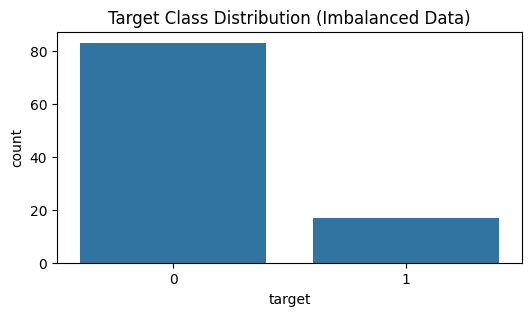

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Sample data generation
np.random.seed(0)
data = pd.DataFrame({
    'numeric_feature': np.random.randn(100),
    'categorical_feature': np.random.choice(['A', 'B', 'C', 'D'], size=100),
    'high_card_feature': np.random.choice([f'category_{i}' for i in range(20)], size=100),
    'missing_feature': np.random.choice([np.nan, 1, 2, 3], size=100),
    'target': np.random.choice([0, 1], size=100, p=[0.8, 0.2])
})
data['sparse_feature'] = data['categorical_feature'].apply(lambda x: 1 if x == 'A' else 0)

# Data validation
def validate_data(df):
    assert all(df['numeric_feature'].between(-5, 5)), "Numeric feature out of range"
    assert df['categorical_feature'].isin(['A', 'B', 'C', 'D']).all(), "Invalid categorical value"
    print('Data validation passed.')

validate_data(data)

# Visualize missing data
plt.figure(figsize=(6, 4))
sns.heatmap(data.isnull(), cbar=False, yticklabels=False)
plt.title('Missing Data Heatmap')
plt.show()

# Handling missing data and scaling
numeric_imputer = SimpleImputer(strategy='mean')
categorical_imputer = SimpleImputer(strategy='most_frequent')

# Feature encoding
onehot_encoder = OneHotEncoder(handle_unknown='ignore')

# High cardinality frequency encoding
freq_encoding = data['high_card_feature'].value_counts(normalize=True)
data['high_card_freq_encoded'] = data['high_card_feature'].map(freq_encoding)

numeric_features = ['numeric_feature', 'missing_feature']
categorical_features = ['categorical_feature']

numeric_transformer = Pipeline([
    ('imputer', numeric_imputer),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', categorical_imputer),
    ('onehot', onehot_encoder)
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Discretization
bins = 5
labels = [f'bin_{i}' for i in range(bins)]
data['numeric_disc'] = pd.cut(data['numeric_feature'], bins=bins, labels=labels)

# Plot discretized numeric feature distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='numeric_disc', data=data)
plt.title('Discretized Numeric Feature Distribution')
plt.show()

# Data integration example
extra_data = pd.DataFrame({
    'id': range(50),
    'extra_info': np.random.randn(50)
})
data = data.reset_index().rename(columns={'index': 'id'})
merged_data = pd.merge(data, extra_data, on='id', how='left')
print('Data integrated. Shape:', merged_data.shape)

# Visualize sparse feature distribution
plt.figure(figsize=(6, 3))
sns.countplot(x='sparse_feature', data=merged_data)
plt.title('Sparse Feature Distribution')
plt.show()

# Train RandomForest classifier with balanced class weights
X = preprocessor.fit_transform(merged_data)
y = merged_data['target']

clf = RandomForestClassifier(random_state=42, class_weight='balanced')
clf.fit(X, y)
y_pred = clf.predict(X)

# Performance report
print(classification_report(y, y_pred))

# Confusion matrix visualization
ConfusionMatrixDisplay.from_estimator(clf, X, y, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# Target class imbalance visualization
plt.figure(figsize=(6,3))
sns.countplot(x='target', data=merged_data)
plt.title('Target Class Distribution (Imbalanced Data)')
plt.show()


RandomForest Classification Report
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        33
           1       0.97      1.00      0.98        28
           2       1.00      1.00      1.00        33
           3       1.00      0.94      0.97        34
           4       0.98      1.00      0.99        46
           5       0.94      0.96      0.95        47
           6       0.97      0.97      0.97        35
           7       0.97      0.97      0.97        34
           8       0.97      0.97      0.97        30
           9       0.95      0.95      0.95        40

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



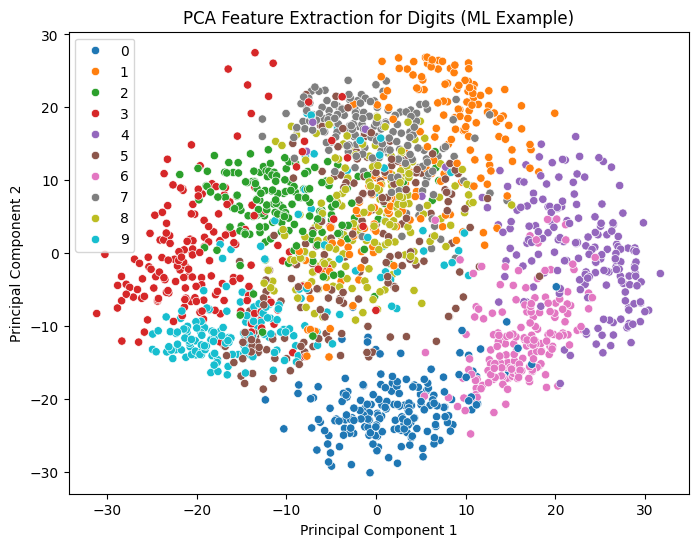

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# ML: RandomForest on digits dataset (simple features)
digits = load_digits()
X, y = digits.data, digits.target

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train RandomForest classifier
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train, y_train)
y_pred_ml = rfc.predict(X_test)

print('RandomForest Classification Report')
print(classification_report(y_test, y_pred_ml))

# Feature extraction with PCA for visualization (ML)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette='tab10', legend='full')
plt.title('PCA Feature Extraction for Digits (ML Example)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ML - RandomForest Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        33
           1       0.97      1.00      0.98        28
           2       1.00      1.00      1.00        33
           3       1.00      0.94      0.97        34
           4       0.98      1.00      0.99        46
           5       0.94      0.96      0.95        47
           6       0.97      0.97      0.97        35
           7       0.97      0.97      0.97        34
           8       0.97      0.97      0.97        30
           9       0.95      0.95      0.95        40

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



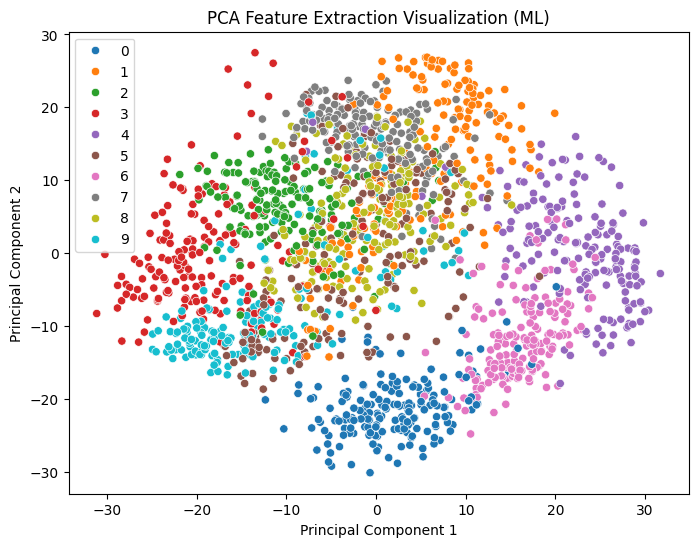

c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9028 - loss: 0.3215 - val_accuracy: 0.9843 - val_loss: 0.0491
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9854 - loss: 0.0484 - val_accuracy: 0.9877 - val_loss: 0.0469
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9903 - loss: 0.0312 - val_accuracy: 0.9900 - val_loss: 0.0377
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9933 - loss: 0.0210 - val_accuracy: 0.9907 - val_loss: 0.0410
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9953 - loss: 0.0148 - val_accuracy: 0.9905 - val_loss: 0.0335
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9872 - loss: 0.0435
DL - CNN Test Accuracy: 0.9905


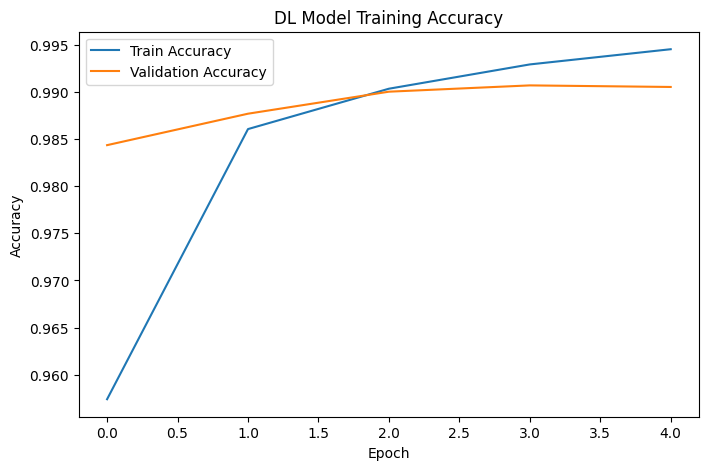

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_19628\3883963778.py:95: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test[:50], feature_names=digits.feature_names)
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\shap\plots\_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\shap\plots\_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning

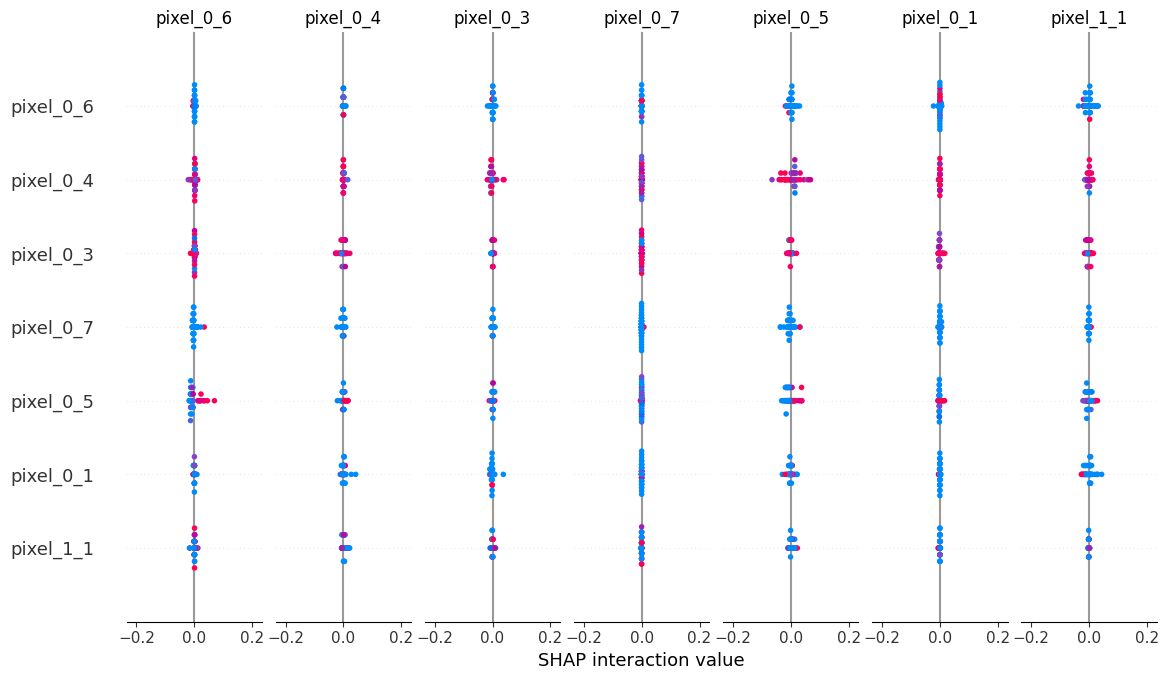

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import shap
import tensorflow as tf
from tensorflow.keras import layers, models

# --- Machine Learning Example: Random Forest on Digits Dataset ---

# Load digits dataset
digits = load_digits()
X, y = digits.data, digits.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train RandomForest classifier
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train, y_train)
y_pred = rfc.predict(X_test)

print("ML - RandomForest Classification Report:")
print(classification_report(y_test, y_pred))

# Feature extraction with PCA for visualization (2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='tab10', legend='full')
plt.title('PCA Feature Extraction Visualization (ML)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


# --- Deep Learning Example: CNN on MNIST Dataset ---

# Load MNIST data
(X_train_dl, y_train_dl), (X_test_dl, y_test_dl) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values
X_train_dl = X_train_dl.astype('float32') / 255.0
X_test_dl = X_test_dl.astype('float32') / 255.0

# Reshape for CNN input
X_train_dl = X_train_dl[..., np.newaxis]
X_test_dl = X_test_dl[..., np.newaxis]

# Build a simple CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the CNN
history = model.fit(X_train_dl, y_train_dl, epochs=5, validation_split=0.1, verbose=1)

# Evaluation
loss, accuracy = model.evaluate(X_test_dl, y_test_dl)
print(f"DL - CNN Test Accuracy: {accuracy:.4f}")

# Plot training history
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('DL Model Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


# --- Explainable AI with SHAP for RandomForest ---

# Create SHAP explainer
explainer = shap.TreeExplainer(rfc)

# Compute SHAP values for a subset (for speed)
shap_values = explainer.shap_values(X_test[:50])

# Summary plot of SHAP values
shap.summary_plot(shap_values, X_test[:50], feature_names=digits.feature_names)
